🎉 데이터 가져오기 성공!
           날짜     검색량_비율
0  2022-02-01    2.13675
1  2022-03-01    2.56410
2  2022-04-01    2.99145
3  2022-05-01    4.48717
4  2022-06-01    4.70085
5  2022-07-01    2.13675
6  2022-08-01    2.35042
7  2022-09-01    6.62393
8  2022-10-01    3.63247
9  2022-11-01    8.33333
10 2022-12-01    2.35042
11 2023-01-01    3.84615
12 2023-02-01    3.63247
13 2023-03-01    2.56410
14 2023-04-01    5.12820
15 2023-05-01   13.24786
16 2023-06-01   15.17094
17 2023-07-01   12.39316
18 2023-08-01    6.41025
19 2023-09-01   15.81196
20 2023-10-01   11.11111
21 2023-11-01    7.05128
22 2023-12-01    6.62393
23 2024-01-01   11.32478
24 2024-02-01   20.72649
25 2024-03-01   31.83760
26 2024-04-01   38.46153
27 2024-05-01   36.96581
28 2024-06-01   38.67521
29 2024-07-01   42.73504
30 2024-08-01   46.36752
31 2024-09-01   62.17948
32 2024-10-01   65.81196
33 2024-11-01   52.99145
34 2024-12-01   47.86324
35 2025-01-01   44.44444
36 2025-02-01   52.77777
37 2025-03-01   85.89743
38 2025-04

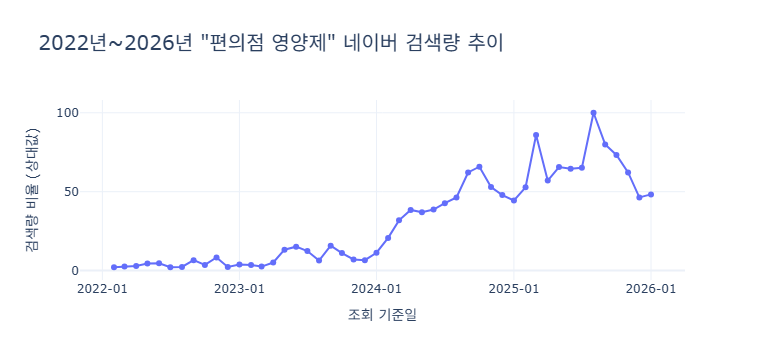

In [8]:
import json
import requests
import pandas as pd
import plotly.express as px

# 1. 네이버 개발자 센터에서 발급받은 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz" # 이미지 속 Client Secret 입력 # 여기에 발급받은 Client Secret을 넣으세요

# 2. API 엔드포인트 설정
url = "https://openapi.naver.com/v1/datalab/search"

# 3. 요청 헤더 설정
headers = {
    "X-Naver-Client-Id": CLIENT_ID,
    "X-Naver-Client-Secret": CLIENT_SECRET,
    "Content-Type": "application/json"
}

# 4. 요청 파라미터 (2023년 ~ 2026년 데이터 설정)
body = {
    "startDate": "2022-01-01",
    "endDate": "2026-01-01",          # 2026년 현재 시점 반영
    "timeUnit": "month",               # 추이를 보기 쉽게 '월간'으로 설정
    "keywordGroups": [
        {
            "groupName": "편의점 영양제",
            "keywords": ["편의점 영양제"]
        }
    ]
}

# 5. API 요청 보내기
response = requests.post(url, headers=headers, data=json.dumps(body))

# 6. 데이터 가공 및 Plotly 시각화
if response.status_code == 200:
    res_json = response.json()
    
    # 결과 데이터에서 날짜와 비율(검색량) 추출
    data_list = res_json['results'][0]['data']
    
    # 판다스 데이터프레임으로 변환
    df = pd.DataFrame(data_list)
    df.columns = ['날짜', '검색량_비율']
    
    # Plotly가 날짜 축을 올바르게 인식하도록 데이터 타입 변환
    df['날짜'] = pd.to_datetime(df['날짜'])
    
    print("🎉 데이터 가져오기 성공!")
    print(df) # 상위 5개 데이터 미리보기
    
    # 7. Plotly를 이용한 인터랙티브 라인 차트 생성
    fig = px.line(
        df, 
        x='날짜', 
        y='검색량_비율', 
        title='2022년~2026년 "편의점 영양제" 네이버 검색량 추이',
        labels={'날짜': '조회 기준일', '검색량_비율': '검색량 비율 (상대값)'},
        markers=True # 데이터 포인트마다 점 표시
    )
    
    # 그래프 스타일 및 레이아웃 미세 조정
    fig.update_layout(
        title_font_size=20,
        xaxis_tickformat='%Y-%m', # X축 날짜 형식을 '년-월'로 지정
        template='plotly_white',  # 깔끔한 흰색 배경 테마
        hovermode='x unified'     # 마우스를 올렸을 때 해당 시점의 데이터 팝업 강조
    )
    
    # Jupyter Notebook에 그래프 출력
    fig.show()

else:
    print(f"❌ API 요청 실패 (에러 코드: {response.status_code})")
    print(response.text)

In [11]:
import urllib.parse
import requests
import pandas as pd

# 1. 네이버 API 키 입력
CLIENT_ID = "iQYuA4jIAZWE78ZCH4p9" # 이미지 속 Client ID 입력
CLIENT_SECRET = "7MP3lY3dzz"

# 2. 검색 설정
keyword = "cu 영양제"
display_count = 50  # 블로그, 카페에서 각각 가져올 글의 개수 (최대 100)

# 검색어를 URL 인코딩
encoded_keyword = urllib.parse.quote(keyword)

# 3. 네이버 검색 API 호출 함수 정의
def get_naver_search(target_type, query, display):
    """
    target_type: 'blog' 또는 'cafearticle'
    """
    url = f"https://openapi.naver.com/v1/search/{target_type}.json?query={query}&display={display}&sort=sim"
    
    headers = {
        "X-Naver-Client-Id": CLIENT_ID,
        "X-Naver-Client-Secret": CLIENT_SECRET
    }
    
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        items = response.json().get('items', [])
        data = []
        for item in items:
            # HTML 태그 제거 및 텍스트 정제
            title = item['title'].replace('<b>', '').replace('</b>', '')
            description = item['description'].replace('<b>', '').replace('</b>', '')
            
            data.append({
                "출처": "블로그" if target_type == "blog" else "카페",
                "제목": title,
                "요약내용": description,
                "링크": item['link']
            })
        return data
    else:
        print(f"❌ {target_type} API 요청 실패: {response.status_code}")
        return []

# 4. 블로그와 카페에서 각각 데이터 수집
print("🔄 네이버 블로그 글 수집 중...")
blog_results = get_naver_search("blog", encoded_keyword, display_count)

print("🔄 네이버 카페 글 수집 중...")
cafe_results = get_naver_search("cafearticle", encoded_keyword, display_count)

# 5. 데이터 통합 및 판다스 데이터프레임 변환
total_results = blog_results + cafe_results

if total_results:
    df_search = pd.DataFrame(total_results)
    print(f"\n🎉 수집 완료! 총 {len(df_search)}개의 글을 수집했습니다.")
    
    # Jupyter Notebook에서 데이터프레임 출력
    # 행이 잘리지 않고 다 보이도록 설정 후 출력
    pd.set_option('display.max_colwidth', None)
    display(df_search.head(30)) # 상위 10개 출력
else:
    print("수집된 데이터가 없습니다. API 키나 키워드를 확인해 주세요.")

🔄 네이버 블로그 글 수집 중...
🔄 네이버 카페 글 수집 중...

🎉 수집 완료! 총 100개의 글을 수집했습니다.


,출처,제목,요약내용,링크
0,블로그,동네 CU 편의점 알바생도 놀란 26년 5월 영양제 90% 할인...,[첫 번째: CU 영양제 90% 할인의 치명적인 함정] 이번 5월 행사의 핵심은 무조건 CU에서 파는... 저는 내일 아침 출근길에도 일찍 CU에 들러서 동네에 남은 영양제 싹쓸이 좀 해보려고요. 다치지 않고 무사히...,https://blog.naver.com/doublepapa/224271893458
1,블로그,cu영양제 비컴플 아르기닌 마그네슘,"cu로부터 제품을 제공받아 쓴 솔직리뷰입니다. 요즘 스트레스로 인한 피로가 누적되면서 가벼운... 사용할 예정이며, 건강 관리가 필요한 분들에게 적극 추천합니다. #cu영양제 #편의점영양제 #비컴플 #비컴플영양제",https://blog.naver.com/eheh1123-/223666546351
2,블로그,cu 토스 영양제 행사 씨유 동아제약 셀파렉스 영양제 정보,cu 토스 영양제 행사해서 사왔는데요 씨유 동아제약 샐파렉스 영양제 정보 입니다 뭔가 포스팅... 영양제 정보였습니다 ⬇️ 할인정보는 요기 #씨유 #영양제 #씨유영양제 #씨유양양제할인 #cu영양제할인...,https://blog.naver.com/llsopiall/224278636896
3,블로그,CU 영양제 토스페이머니 130알 3900원 구매후기,"오늘은 CU 영양제 구입 행사로 영양제 130알을 3,900원에 구입한 후기 남겨볼게요. 아래 결제... CU 앱, 토스페이머니 (필수 O) 상위 링크가 이벤트 페이지고요! 아래서 캡처 본으로 보여드릴게요. 5월 내내...",https://blog.naver.com/koya0205/224279168145
4,블로그,cu 영양제 90% 할인받아 500원에 구매 성공 내돈내산,"일단 cu에서 어떤 이벤트 진행 중인지 알려드릴게요! 영양제 종류도 다양해요! 동생 5개, 저 5개 구매해 봤습니다. 유통기한도 제일 긴 게 27년 8월 19일 ~ 제일 짧은 게 27년 7월 8일 충분하죠 ? 동생은 다이어트...",https://blog.naver.com/eunhye-_-99/224276364879
5,블로그,CU 편의점 다이어트 영양제 &lt;종근당 건강프로젝트365...,그래서 쉽고 간편하게 접근성이 쉬운 CU 편의점 다이어트 영양제를 구입했어요! 12월은 1+1 이벤트... CU 영양제로 체중감량 꼭 성공해서 2026년은 늘씬해질 수 있기를 바라고 있어요. 종근당에서 만든 제품이니까...,https://blog.naver.com/mima44/224118683482
6,블로그,다리 붓기 고민하다 발견한 CU편의점 가성비 영양제,"그래서 영양제를 챙겨 먹어야겠다고 생각하던 중, 우연히 CU편의점에서 영양제를 발견하게 됐습니다.... #CU영양제 #편의점영양제 #가성비영양제 #혈행건강 #뼈건강 #이너케어 #다리붓기 #혈액순환 #건강관리...",https://blog.naver.com/euleul-/224233251512
7,블로그,어버이날 선물 고민 끝 CU 영양제 3900원 득템,용돈이랑 엄빠 갔다드려야지❤️ 저렴하게 영양제 겟하려면 언능 CU달려가세욤!! #짠테크 #편의점꿀템 #CU추천 #종근당 #어버이날선물 #가성비선물 #신혼부부절약 #생활비절약 #소소한행복 #득템,https://blog.naver.com/yeran0702/224275476891
8,블로그,CU 편의점 영양제 비컴플 2종 마그네슘 아르기닌,"CU 편의점 영양제 안녕하세요 오늘 소개해드리는 건 CU 영양제 비컴플 2종입니다. 편의점에서는 먹을 거만 사봤지, 한 번도 영양제를 구매해 본 적이 없는데요. 사실 있는지도 몰랐어요... 그래서 궁금하기도 해서...",https://blog.naver.com/mukningen/223671075521
9,블로그,CU 편의점 5월 행사! 영양제·단백질쉐이크 1+1 &amp; 최대 75...,포켓cu픽업 #포켓cu쿠폰 #cu편의점행사 #cu편의점할인 #cu편의점5월행사 #cu편의점이벤트 #cu영양제... CU편의점행사 #CU5월이벤트 #영양제1+1 #프로틴쉐이크1+1 #편의점세일 #CU할인정보 #다이어트간편식...,https://blog.naver.com/na21100/223861013572
